#  Blinkit Inventory Data Analysis

##  Overview
This project focuses on analyzing inventory and sales data from Blinkit to uncover actionable insights for improving inventory management, reducing stock inefficiencies, and optimizing product availability.

Efficient inventory management is crucial for quick-commerce platforms like Blinkit, where demand fluctuates rapidly and product availability directly impacts customer satisfaction and revenue.

---

##  Objectives
The main goals of this project are:

- Analyze sales and demand patterns across products and categories  
- Identify overstocked and understocked items  
- Measure inventory efficiency using key metrics  
- Detect stockout risks and slow-moving products  
- Provide business recommendations for better inventory planning  

---

##  Dataset Description
The dataset includes information such as:

- Product details (category, pricing, etc.)  
- Inventory levels  
- Sales and demand data  
- Expiry-related information  

---

##  Key Metrics Created
To enhance the analysis, several derived metrics were created:

- **Inventory Turnover Ratio** – Measures how efficiently inventory is sold  
- **Demand-Stock Gap** – Difference between demand and available stock  
- **Stockout Risk Indicator** – Identifies products likely to run out of stock  
- **Overstock Indicator** – Highlights excess inventory  
- **Days to Expiry / Product Age** – Helps track perishable inventory  

---

##  Tools & Technologies
- Python  
- Pandas & NumPy  
- Matplotlib & Seaborn  
- Jupyter Notebook  

---

##  Project Workflow
1. Data Cleaning & Preprocessing  
2. Feature Engineering  
3. Exploratory Data Analysis (EDA)  
4. Insight Generation  
5. Business Recommendations  

In [1]:
# importing necessary python libraries
# import numpy
import numpy as np 
# import pandas
import pandas as pd
# import subpackages of matplotlib
import matplotlib.pyplot as plt
# import seaborn
import seaborn as sns

In [2]:
# loading the dataset
df = pd.read_csv("Downloads/blinkit_dataset.csv")

In [20]:
df.head()

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status,inventory_turnover,demand_stock_gap
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,750,212,15,73,2023-11-27,2024-06-26,No offer,On-Time,3.129870,-3
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,1000,17,24,25,2024-08-07,2024-08-24,No offer,Delayed,0.227642,-97
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time,4.590551,-26
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,200,1143,18,15,2024-08-07,2027-09-24,No offer,On-Time,0.354839,-77
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,300,363,30,6,2024-07-04,2025-07-02,No offer,On-Time,0.313725,-146


##  Dataset Columns & Description
---
| Column Name        | Description |
|:------------------ |:------------|
| product_id        | Unique identifier assigned to each product |
| product_name      | Name of the product listed on the platform |
| category          | Product category (e.g., Grocery, Dairy, Beverages) |
| brand             | Brand name of the product |
| price             | Original price of the product before discount |
| discount_pct      | Discount percentage applied on the product |
| final_price       | Final selling price after applying discount |
| rating            | Average customer rating of the product (out of 5) |
| num_reviews       | Total number of customer reviews |
| delivery_time_min | Estimated delivery time in minutes |
| delivery_status   | Status of delivery (e.g., On-Time, Delayed) |
| stock             | Current available inventory for the product |
| sold_quantity     | Total units sold |
| reorder_level     | Minimum stock level at which product should be restocked |
| demand_index      | Indicator representing product demand level |
| profit_margin_pct | Profit margin percentage on the product |
| is_organic        | Indicates whether the product is organic (True/False) |
| packaging_type    | Type of packaging (e.g., Can, Jar, Bottle) |
| weight_g          | Weight of the product in grams |
| shelf_life_days   | Number of days the product remains usable |
| date_added        | Date when the product was added to inventory |
| expiry_date       | Expiry date of the product |
| offer_type        | Type of promotional offer (if any) |
| seller            | Seller or vendor providing the product |
| city              | City where the product is available |

In [4]:
# Getting detailed information about the dataset (data types, non-null counts, etc.)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         13000 non-null  int64  
 1   product_name       13000 non-null  object 
 2   category           13000 non-null  object 
 3   brand              13000 non-null  object 
 4   price              13000 non-null  float64
 5   discount_pct       13000 non-null  int64  
 6   final_price        13000 non-null  float64
 7   rating             13000 non-null  float64
 8   num_reviews        13000 non-null  int64  
 9   delivery_time_min  13000 non-null  int64  
 10  city               13000 non-null  object 
 11  seller             13000 non-null  object 
 12  stock              13000 non-null  int64  
 13  sold_quantity      13000 non-null  int64  
 14  profit_margin_pct  13000 non-null  float64
 15  is_organic         13000 non-null  bool   
 16  packaging_type     130

##  Data Quality

###  Data Overview
- Total Records: **13,000**
- Total Columns: **25**
- Memory Usage: **~2.4 MB**

---

###  Data Quality Checks

-  **No Missing Values** in most columns  
-  `offer_type` has **missing values (approx. 50%)**, indicating that not all products have offers  
-  No duplicate column names detected  
-  Dataset size is manageable and suitable for analysis  

---

###  Data Type Evaluation

| Column Type | Columns | Assessment |
|:------------|:--------|:-----------|
| Integer (`int64`) | product_id, discount_pct, num_reviews, stock, sold_quantity, reorder_level, demand_index, etc. |  Appropriate for count-based and discrete values |
| Float (`float64`) | price, final_price, rating, profit_margin_pct |  Correct for continuous numerical values |
| Boolean (`bool`) | is_organic |  Correct for True/False values |
| Object (`object`) | product_name, category, brand, city, seller, packaging_type |  Suitable for categorical/text data |
| Object (Date fields) | date_added, expiry_date |  Should be converted to **datetime format** |

---

###  Data Quality Issues Identified

- `date_added` and `expiry_date` are stored as **object (string)** instead of datetime  
- `offer_type` contains **missing values**  
- Some categorical columns may need **encoding** for modeling  

In [5]:
# changing datatype :-
df['date_added'] = pd.to_datetime(df['date_added'])
df['expiry_date'] =pd.to_datetime(df['expiry_date'])

In [6]:
# handling the missing values :-
df['offer_type'] = df['offer_type'].fillna('No offer')

##  Handling Missing Values

###  Missing Value Treatment

- The column `offer_type` contained missing values for several records.
- These missing values indicate that no promotional offer was applied to those products.

###  Approach Used

- Missing values in `offer_type` were filled with **"No Offer"** to maintain consistency and avoid data loss.

#  Feature Engineering

## Inventory Turnover

###  Objective
To measure how efficiently inventory is being utilized, a new metric called **Inventory Turnover** is created.

###  Definition

- **Inventory Turnover** indicates how quickly stock is sold relative to available inventory.
- It helps identify:
  - Fast-moving products
  - Slow-moving or overstocked items

---

### Formula

Inventory Turnover = Sold Quantity / Available Stock



In [25]:
df['inventory_turnover'] = df['sold_quantity'] / (df['stock'] + 1) # +1 to avoid division by zero 
df['inventory_turnover']

0        3.129870
1        0.227642
2        4.590551
3        0.354839
4        0.313725
           ...   
12995    1.422535
12996    0.656250
12997    1.147059
12998    0.354839
12999    0.457447
Name: inventory_turnover, Length: 13000, dtype: float64

## Demand-Stock Gap

###  Objective
To identify the mismatch between product demand and available inventory, a new metric called **Demand-Stock Gap** is created.

---

###  Definition

- **Demand-Stock Gap** measures the difference between customer demand and current stock levels.
- It helps detect:
  - Potential stock shortages
  - Overstock situations

---

###  Formula

Demand-Stock Gap = Demand Index − Stock

In [26]:
df['demand_stock_gap'] = df['demand_index'] - df['stock']
df['demand_stock_gap']

0         -3
1        -97
2        -26
3        -77
4       -146
        ... 
12995    -68
12996    -60
12997    -67
12998   -106
12999    -72
Name: demand_stock_gap, Length: 13000, dtype: int64

##  Stockout Risk Identification

###  Objective
To identify products that are at high risk of going out of stock by analyzing current inventory levels and demand patterns.

---

###  Definition

A product is considered at **stockout risk** if:
- Its current stock is **below the reorder level**, and  
- Its demand is **higher than average demand**

---

###  Logic Used

Stockout Risk Condition:
- `stock < reorder_level`  
- `demand_index > average demand_index`


In [27]:
# high demand but low stock
stockout_risk = df[(df['stock'] < df['reorder_level']) & (df['demand_index'] > df['demand_index'].mean())]
stockout_risk

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status,inventory_turnover,demand_stock_gap


##  Overstock Identification

###  Objective
To identify products that are overstocked and not selling efficiently, leading to increased holding costs and potential wastage.

---

###  Definition

A product is considered **overstocked** if:
- Its current stock is **higher than the reorder level**, and  
- Its sales are **lower than the average sold quantity**

---

###  Logic Used

Overstock Condition:
- `stock > reorder_level`  
- `sold_quantity < average sold_quantity`

In [28]:
# high stock low sales
overstock = df[(df['stock'] > df['reorder_level']) & (df['sold_quantity'] < df['sold_quantity'].mean())]
overstock

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status,inventory_turnover,demand_stock_gap
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,1000,17,24,25,2024-08-07,2024-08-24,No offer,Delayed,0.227642,-97
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,200,1143,18,15,2024-08-07,2027-09-24,No offer,On-Time,0.354839,-77
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,300,363,30,6,2024-07-04,2025-07-02,No offer,On-Time,0.313725,-146
6,7,Britannia Organic Bakery 192,Bakery,Britannia,390.21,0,390.21,3.8,212,33,...,750,7,19,12,2024-06-08,2024-06-15,FreeDelivery,On-Time,0.440000,-87
7,8,Britannia Premium Bakery 931,Bakery,Britannia,370.21,10,333.19,4.2,37,34,...,200,8,19,34,2024-11-21,2024-11-29,FlatDiscount,On-Time,0.969072,-62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12994,12995,Dettol Lite Household 374,Household,Dettol,493.99,30,345.79,4.5,43,21,...,750,940,22,47,2024-09-25,2027-04-23,No offer,On-Time,1.274336,-65
12996,12997,FreshFarm Organic Fruits 225,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,115,25,...,1000,13,19,35,2024-01-11,2024-01-24,Cashback,On-Time,0.656250,-60
12997,12998,FreshFarm Original Fruits 349,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,199,19,...,1000,3,20,34,2025-08-08,2025-08-11,No offer,On-Time,1.147059,-67
12998,12999,Lizol Lite Household 792,Household,Lizol,435.70,5,413.91,3.4,114,18,...,500,403,24,17,2023-11-11,2024-12-18,No offer,On-Time,0.354839,-106


##  Days to Expiry

### Objective  
To calculate the lifespan of a product from the date it was added until its expiry date. This helps in identifying perishable items and managing inventory efficiently.

---

### Definition
Days to Expiry represents the number of days between the product's expiry date and the date it was added to the inventory.

---

### Logic Used
- The `expiry_date` column is subtracted from the `date_added` column.
- This gives a time difference (timedelta).
- The number of days is extracted using `.dt.days`.

In [87]:
# days to expiry 
df['days_to_expiry'] = (df['expiry_date'] - df['date_added']).dt.days
df['days_to_expiry']

0         212
1          17
2        1463
3        1143
4         363
         ... 
12995     482
12996      13
12997       3
12998     403
12999    1279
Name: days_to_expiry, Length: 13000, dtype: int64

## Product Age

### Objective 
To measure how long a product has been in the inventory since it was added. This helps in identifying old stock, slow-moving items, and potential dead inventory.

---

### Definition 
Product Age represents the number of days between the current date and the date when the product was added to the system.

---

### Logic Used  
- The current date is obtained using `pd.to_datetime('today')`.
- The `date_added` column is subtracted from the current date.
- The result is a time difference (timedelta), from which only the number of days is extracted using `.dt.days`.

In [85]:
# production age 
df['product_age'] = (pd.to_datetime('today') - df['date_added']).dt.days
df['product_age']

0        861
1        607
2        764
3        607
4        641
        ... 
12995    445
12996    816
12997    241
12998    877
12999    638
Name: product_age, Length: 13000, dtype: int64

##  Fast-Moving Products Identification

###  Objective
To identify products that are selling quickly and have high inventory turnover, indicating strong demand and efficient stock movement.

---

###  Definition

A product is considered **fast-moving** if:
- Its inventory turnover is **higher than the average inventory turnover**

---

###  Logic Used

Fast-Moving Condition:
- `inventory_turnover > average inventory_turnover`

In [29]:
fast_moving = df[df['inventory_turnover'] > df['inventory_turnover'].mean()]
fast_moving

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status,inventory_turnover,demand_stock_gap
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,750,212,15,73,2023-11-27,2024-06-26,No offer,On-Time,3.129870,-3
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time,4.590551,-26
5,6,Britannia Premium Snacks 284,Snacks,Britannia,250.33,5,237.81,4.4,451,14,...,500,168,22,80,2025-08-29,2026-02-13,No offer,On-Time,2.495652,-34
10,11,Harpic Premium Household 296,Household,Harpic,897.93,10,808.14,3.8,164,28,...,250,627,24,51,2025-09-02,2027-05-22,No offer,On-Time,1.584000,-73
11,12,Lizol Fresh Household 602,Household,Lizol,163.87,5,155.68,4.1,247,29,...,1000,612,20,33,2024-07-07,2026-03-11,No offer,On-Time,1.876190,-71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12977,12978,DailyGreens Classic Fruits 242,Fruits & Vegetables,DailyGreens,324.20,15,275.57,3.9,149,28,...,1000,7,24,97,2024-11-22,2024-11-29,Cashback,Delayed,3.398374,-25
12979,12980,Dove Daily Personal 391,Personal Care,Dove,567.40,20,453.92,3.4,225,30,...,200,825,16,68,2025-05-20,2027-08-23,No offer,Delayed,3.317647,-16
12984,12985,Harpic Organic Household 146,Household,Harpic,876.28,15,744.84,4.3,76,23,...,750,572,23,41,2024-01-19,2025-08-13,No offer,On-Time,1.601695,-76
12985,12986,Gowardhan Lite Dairy 154,Dairy,Gowardhan,237.93,0,237.93,4.6,420,24,...,250,11,28,80,2025-01-05,2025-01-16,No offer,On-Time,1.868966,-64


##  Dead Stock Identification

###  Objective
To identify products that are not selling at all despite being available in inventory, leading to blocked capital and storage inefficiency.

---

###  Definition

A product is considered **dead stock** if:
- It has **zero sales**, and  
- It still has **available inventory**

---

###  Logic Used

Dead Stock Condition:
- `sold_quantity == 0`  
- `stock > 0`

In [30]:
dead_stock = df[(df['sold_quantity'] == 0) & (df['stock'] > 0)]
dead_stock

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status,inventory_turnover,demand_stock_gap
120,121,BakeHouse Lite Bakery 837,Bakery,BakeHouse,363.60,25,272.70,3.9,370,28,...,1000,12,15,8,2025-04-09,2025-04-21,No offer,Delayed,0.0,-71
388,389,BakeHouse Organic Bakery 844,Bakery,BakeHouse,474.07,20,379.26,4.0,96,26,...,100,9,24,11,2024-11-27,2024-12-06,Buy1Get1,On-Time,0.0,-109
465,466,P&G Classic Personal 199,Personal Care,P&G,259.35,15,220.45,3.4,204,21,...,200,567,19,3,2025-06-11,2026-12-30,Buy1Get1,On-Time,0.0,-94
671,672,Amul Premium Dairy 831,Dairy,Amul,147.82,15,125.65,4.1,618,30,...,250,7,20,20,2024-02-13,2024-02-20,FlatDiscount,Delayed,0.0,-82
1124,1125,Modern Family Pack Bakery 584,Bakery,Modern,386.99,0,386.99,3.8,228,28,...,100,7,16,0,2024-11-19,2024-11-26,No offer,On-Time,0.0,-81
1170,1171,Aavin Premium Dairy 435,Dairy,Aavin,228.86,30,160.20,4.8,302,31,...,750,17,22,0,2025-09-17,2025-10-04,No offer,Delayed,0.0,-112
1373,1374,DailyGreens Lite Fruits 244,Fruits & Vegetables,DailyGreens,163.37,0,163.37,4.6,275,37,...,2000,9,23,8,2024-01-16,2024-01-25,Cashback,On-Time,0.0,-109
1629,1630,Lay's Daily Snacks 632,Snacks,Lay's,249.88,20,199.90,4.4,309,35,...,100,85,18,13,2025-07-27,2025-10-20,Buy1Get1,On-Time,0.0,-78
1646,1647,ITC Original Snacks 842,Snacks,ITC,235.01,10,211.51,4.1,444,17,...,1000,299,26,5,2025-02-17,2025-12-13,No offer,On-Time,0.0,-129
1724,1725,Parle Lite Snacks 148,Snacks,Parle,71.49,10,64.34,3.5,295,33,...,300,296,26,0,2024-01-26,2024-11-17,No offer,On-Time,0.0,-134


# Exploratory Data Analysis

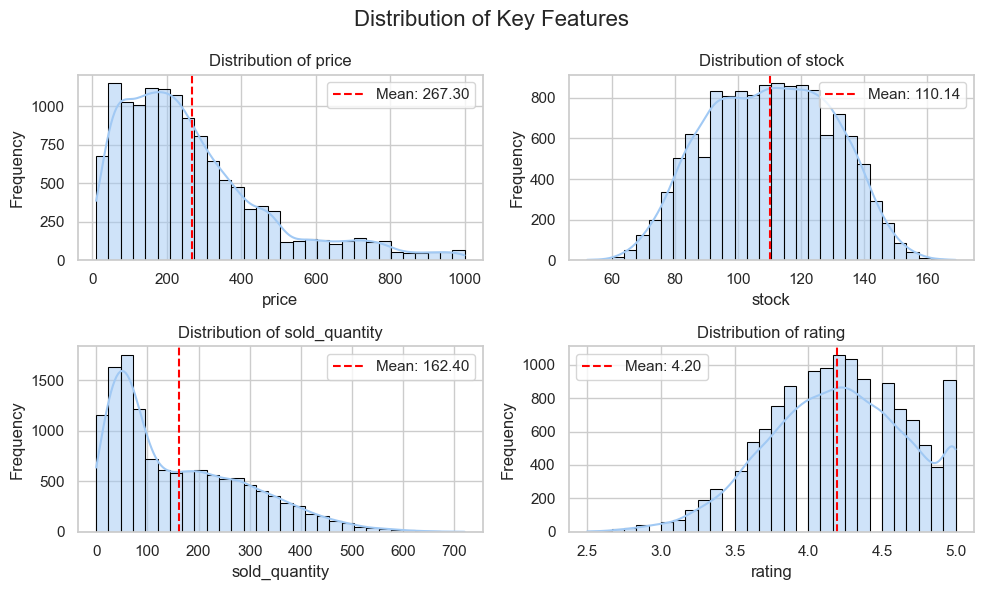

In [22]:
# Style setup
sns.set(style="whitegrid", palette="pastel")

cols = ['price','stock','sold_quantity','rating']

plt.figure(figsize=(10,6))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    
    sns.histplot(df[col],bins=30,kde=True,edgecolor='black')
    
    # Mean line
    mean_val = df[col].mean()
    plt.axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.2f}")
    
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()

plt.suptitle("Distribution of Key Features", fontsize=16)
plt.tight_layout()
plt.show()

#  Distribution of Key Features

##  Overview

This chart shows the distribution of **price, stock, sold quantity, and rating**, along with their mean values.

---

##  Price Distribution

- **Mean price ≈ 267**
- Right-skewed distribution (long tail toward higher prices)
- Majority of products are priced in the **low-to-mid range (0–400)**

**Insight:**  
- Most products are **affordable**, with a few premium/high-priced outliers.
- Pricing strategy is likely **volume-driven**, not premium-focused.

---

##  Stock Distribution

- **Mean stock ≈ 110**
- Roughly **normal (bell-shaped) distribution**
- Most stock levels fall between **80–140**

**Insight:**  
- Inventory is **well-balanced and standardized**
- Indicates controlled supply planning with minimal extreme overstocking

---

##  Sold Quantity Distribution

- **Mean sales ≈ 162**
- Strong **right-skewed distribution**
- Majority of products have **low-to-moderate sales**, with few high performers

**Insight:**  
- Sales follow a **long-tail pattern**
  - Few products drive most revenue (top sellers)
  - Many products have low sales

---

##  Rating Distribution

- **Mean rating ≈ 4.2**
- Slightly **left-skewed (clustered toward higher ratings)**
- Most ratings lie between **3.8–4.8**

**Insight:**  
- Overall product quality/customer satisfaction is **high**
- Limited number of poorly rated products

---

##  Notable Patterns

- **Price vs Sales imbalance**
  - Many low-priced items don’t necessarily achieve high sales

- **Long-tail sales effect**
  - Business likely depends heavily on **top-performing products**

- **Consistently high ratings**
  - Low variance reduces rating as a strong differentiator

---

##  Strategic Takeaways

- Focus on **top-selling products** (Pareto principle: 80/20 rule)
- Optimize pricing in the **high-density range (0–400)**
- Maintain current **inventory consistency**
- Improve differentiation beyond ratings (since most are already high)

---

##  Key Takeaway

> The business shows a **long-tail sales pattern**, with stable inventory and high ratings,  
> but revenue is likely concentrated in a small subset of products.

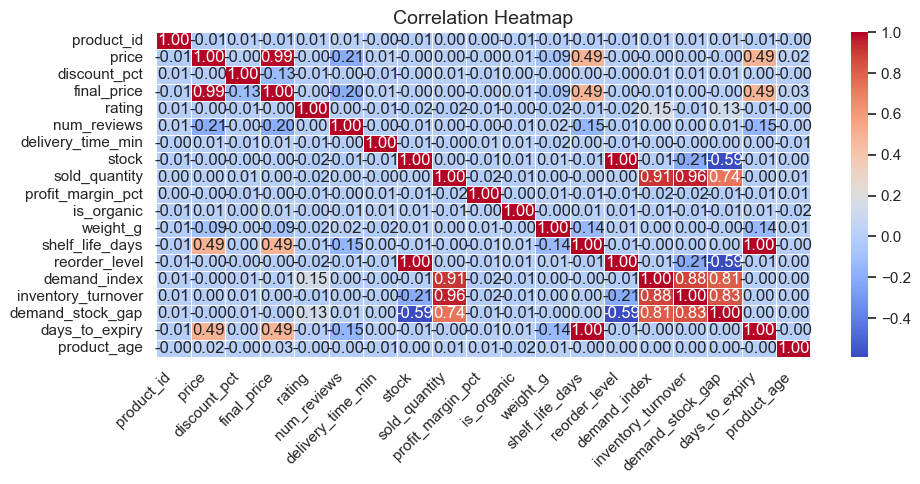

In [86]:
# Correlation Analysis
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,5))

sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm", linewidths=0.5,linecolor='white',cbar=True)

plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#  Correlation Heatmap Insights

##  Key Correlations

###  Pricing & Discounts
- **price ↔ final_price: 0.99 (very strong positive)**
  - Final price is almost entirely driven by base price.

- **discount_pct ↔ final_price: -0.13 (weak negative)**
  - Discounts slightly reduce final price, but impact is relatively small.

---

###  Sales & Demand

- **sold_quantity ↔ demand_index: 0.91 (very strong positive)**
  - Higher demand directly drives higher sales.

- **sold_quantity ↔ inventory_turnover: 0.96 (very strong positive)**
  - Faster inventory movement is tightly linked with sales volume.

- **sold_quantity ↔ demand_stock_gap: 0.74 (strong positive)**
  - When demand exceeds stock, sales still remain high (potential unmet demand).

---

###  Demand & Inventory Efficiency

- **demand_index ↔ inventory_turnover: 0.88 (strong positive)**
  - High-demand products rotate inventory faster.

- **demand_index ↔ demand_stock_gap: 0.81 (strong positive)**
  - High demand often leads to stock shortages.

- **inventory_turnover ↔ demand_stock_gap: 0.83 (strong positive)**
  - Faster turnover is associated with stock gaps → possible understocking.

---

###  Stock & Supply Issues

- **stock ↔ demand_stock_gap: -0.59 (moderate negative)**
  - Higher stock reduces the demand-supply gap.

- **stock ↔ inventory_turnover: -0.21 (weak negative)**
  - More stock doesn’t necessarily mean faster sales → inefficiency risk.

---

###  Ratings & Reviews

- **rating ↔ demand_index: 0.15 (weak positive)**
  - Better ratings slightly increase demand.

- **num_reviews ↔ price: -0.21 (weak negative)**
  - Lower-priced products tend to have more reviews.

---

###  Product Characteristics

- **price ↔ shelf_life_days: 0.49 (moderate positive)**
  - Higher-priced products tend to have longer shelf life.

- **weight_g ↔ shelf_life_days: -0.14 (weak negative)**
  - Heavier products slightly correlate with shorter shelf life.

---

##  Low / No Correlation Areas

- **profit_margin_pct** shows near-zero correlation with most variables  
  → margins are likely controlled independently.

- **delivery_time_min** has negligible impact on sales or demand.

- **is_organic** does not significantly influence sales or demand patterns.

---

##  Strategic Insights

- Focus on **demand forecasting** → strongest driver of sales.
- Optimize **inventory levels** to reduce `demand_stock_gap`.
- Avoid overstocking → does not improve sales significantly.
- Improve **ratings & reviews** for marginal demand lift.
- Pricing strategy should consider **elasticity beyond simple discounts**.

---

##  Key Takeaway

> Sales performance is primarily driven by **demand and inventory efficiency**,  
> while pricing, discounts, and product attributes play a **secondary role**.

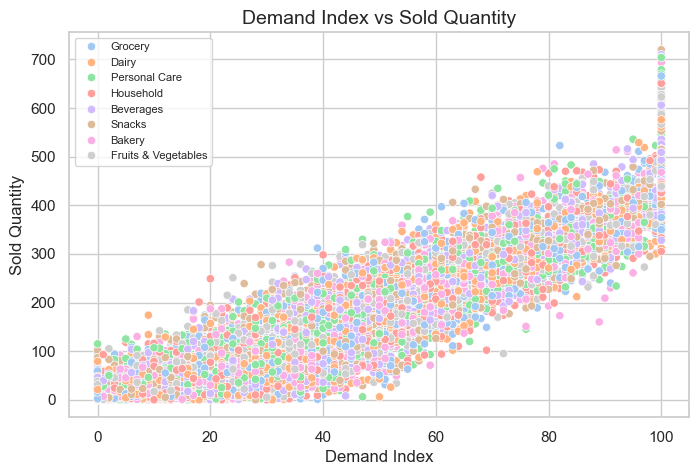

In [67]:
# demand index vs sold quantity
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="demand_index", y="sold_quantity",hue="category",alpha=1.0)
plt.title("Demand Index vs Sold Quantity", fontsize=14)
plt.xlabel("Demand Index")
plt.ylabel("Sold Quantity")
plt.legend(fontsize=8)
plt.grid(True)

plt.show()

###  Demand Index vs Sold Quantity - Insights

- There is a **strong positive relationship** between demand index and sold quantity.  
  As the demand index increases, the number of units sold also increases significantly.

- At **low demand index (0–30)**, sales are generally low and more scattered, indicating inconsistent demand.

- In the **mid-range demand (30–70)**, sales start increasing steadily, showing stable product performance.

- At **high demand index (70–100)**, there is a clear surge in sales, with many products achieving high sold quantities.

- A few **outliers** are visible where products have extremely high sales even at similar demand levels, indicating:
  - Highly popular products  
  - Strong brand influence or promotions  

- The spread of data points increases as demand increases, suggesting **higher variability in sales for high-demand products**.

- Bubble sizes (price) indicate that both **low and high-priced products can perform well**, meaning price is not the only driver of sales.

---

###  Conclusion

- **Demand index is a key driver of sales performance.**
- Businesses should focus on improving product demand (marketing, visibility, offers) to increase sales.
- High-demand products should be prioritized for **inventory and stock planning**.

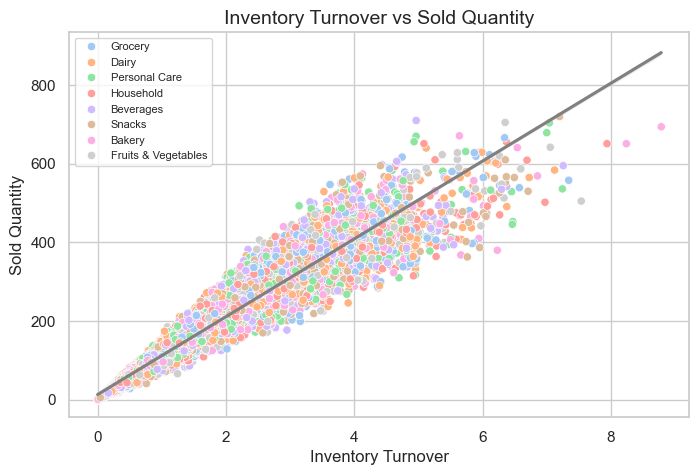

In [62]:
# Inventory Turnover vs Sold Quantity
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x='inventory_turnover',y='sold_quantity',
                 hue='category',        # color by category
                 alpha=1.0)

# Add trend line
sns.regplot(data=df,x='inventory_turnover',y='sold_quantity',scatter=False,color='grey')

plt.title("Inventory Turnover vs Sold Quantity", fontsize=14)
plt.xlabel("Inventory Turnover")
plt.ylabel("Sold Quantity")
plt.legend(fontsize=8)
plt.grid(True)

plt.show()

###  Inventory Turnover vs Sold Quantity - Insights

- There is a **strong positive linear relationship** between inventory turnover and sold quantity.  
  Products with higher turnover rates tend to have significantly higher sales.

- At **low inventory turnover (0–2)**, sold quantity is relatively low, indicating slow-moving products.

- In the **mid-range turnover (2–5)**, sales increase steadily, showing balanced inventory movement.

- At **high turnover levels (5+)**, products achieve very high sales, indicating **fast-moving and high-demand items**.

- The regression line confirms a **clear upward trend**, meaning inventory efficiency directly impacts sales performance.

- Different categories follow a similar trend, suggesting that **inventory turnover is a consistent performance indicator across categories**.

- Slight dispersion at higher turnover levels indicates **variability in sales**, possibly due to pricing, demand, or promotions.

---

###  Conclusion

- **Inventory turnover is a key metric for sales performance.**
- High turnover products should be prioritized for **restocking and inventory planning**.
- Low turnover items may indicate **overstocking or low demand**, requiring discounts or promotional strategies.

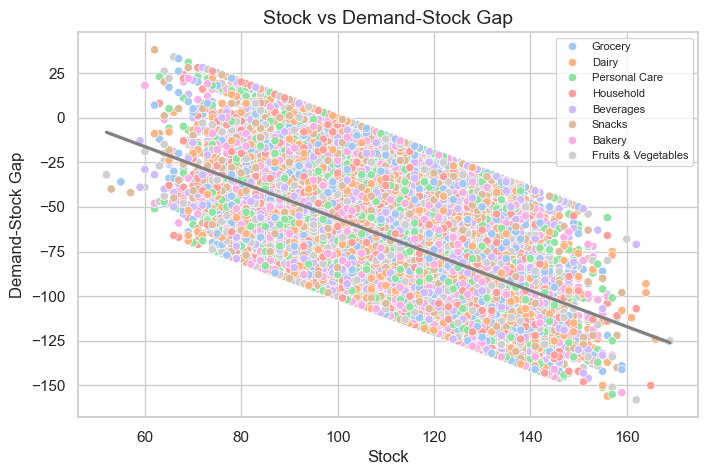

In [68]:
# Stock vs Demand-Stock Gap
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x="stock",y="demand_stock_gap",hue="category",       # compare categories 
                alpha=1.0)

# Add trend line
sns.regplot(data=df,x="stock",y="demand_stock_gap",scatter=False,color="grey")

plt.title("Stock vs Demand-Stock Gap", fontsize=14)
plt.xlabel("Stock")
plt.ylabel("Demand-Stock Gap")
plt.legend(fontsize=8)
plt.grid(True)

plt.show()

###  Stock vs Demand-Stock Gap - Insights

- There is a **strong negative relationship** between stock and demand-stock gap.  
  As stock increases, the demand-stock gap becomes more negative.

- A **negative gap (below 0)** indicates that stock is higher than demand, meaning **overstocking**.

- Most data points lie in the **negative region**, suggesting that a large number of products are overstocked.

- At **higher stock levels (120+)**, the gap becomes significantly negative, indicating **excess inventory buildup**.

- At **lower stock levels (60–80)**, the gap is closer to zero or slightly positive, meaning **better demand-stock balance**.

- The regression line clearly shows a **downward trend**, confirming that increasing stock without matching demand leads to inefficiency.

- All categories follow a similar pattern, indicating that **overstocking is a common issue across categories**.

---

###  Conclusion

- The business is facing a **systematic overstocking problem**.
- Increasing stock does not necessarily increase sales or demand.
- Better **demand forecasting and inventory planning** is required.
- Focus should be on maintaining an **optimal stock level** rather than overstocking products.

C:\Users\Dell\AppData\Local\Temp\ipykernel_11032\1107702501.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.values,y=cat_sales.index,palette="viridis")


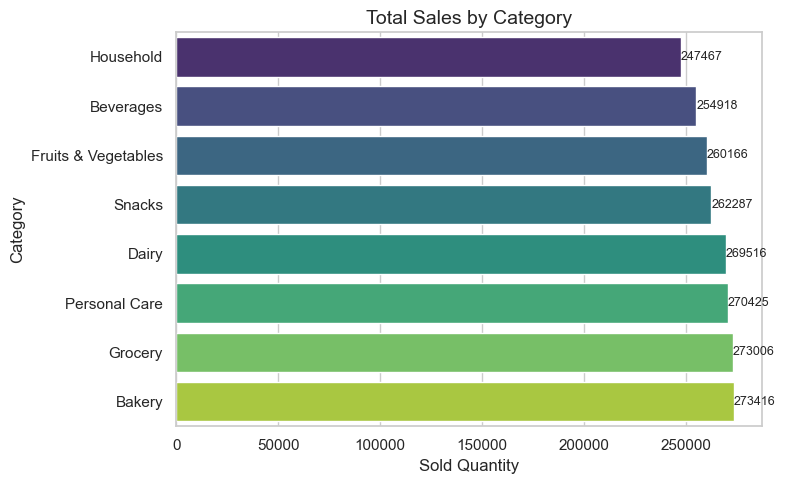

In [99]:
# Total Sales by Category
cat_sales = df.groupby('category')['sold_quantity'].sum().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=cat_sales.values,y=cat_sales.index,palette="viridis")

# Add value labels
for i, v in enumerate(cat_sales.values):
    plt.text(v, i, f"{v:.0f}", va='center', fontsize=9)

plt.title("Total Sales by Category", fontsize=14)
plt.xlabel("Sold Quantity")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

##  Insights from “Total Sales by Category” Chart

###  Top-performing Category
- **Bakery** has the highest sales (~273,416 units), indicating strong customer demand and frequent purchases.

###  Close Contenders
- **Grocery** (273,006) and **Personal Care** (270,425) closely follow Bakery.
- These categories form the **top sales tier** with very small differences between them.

###  Mid-range Performers
- **Dairy** (269,516) and **Snacks** (262,287) show solid and consistent performance.
- Likely represent everyday essential purchases.

###  Moderate Demand Categories
- **Fruits & Vegetables** (260,166) and **Beverages** (254,918) fall in the middle-lower range.
- Possible reasons: perishability or less bulk purchasing.

###  Lowest-performing Category
- **Household** (~247,467) has the lowest sales.
- Suggests less frequent purchases or longer product usage cycles.

---

##  Key Takeaways

- Sales are **fairly evenly distributed** across all categories.
- **Bakery, Grocery, and Personal Care** dominate overall sales.
- **No extreme outliers**, indicating balanced category performance.
- **Growth opportunities** exist in:
  - Household  
  - Beverages  
- Consider **promotions, bundling, or targeted marketing** to boost lower-performing categories.

---

##  Conclusion

Overall, the sales distribution across categories is relatively balanced, with **Bakery, Grocery, and Personal Care** leading slightly ahead. The narrow gaps between categories indicate consistent consumer demand across product types rather than reliance on a single segment. While essential goods drive the majority of sales, there is clear potential to improve performance in lower-ranking categories like **Household** and **Beverages** through strategic initiatives such as pricing, promotions, and product positioning.

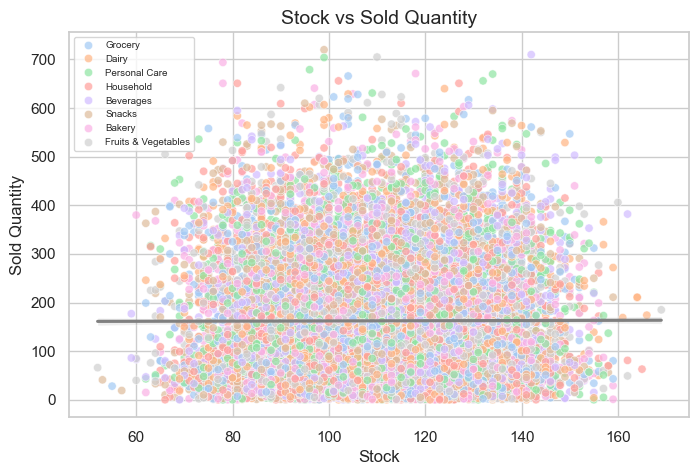

In [80]:
# Stock vs Sold Quantity
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x='stock',y='sold_quantity',hue='category',alpha=0.7)

# Add regression line
sns.regplot( data=df,x='stock',y='sold_quantity',scatter=False, color='grey')

plt.title("Stock vs Sold Quantity", fontsize=14)
plt.xlabel("Stock")
plt.ylabel("Sold Quantity")
plt.legend(fontsize=7)
plt.grid(True)

plt.show()

##  Insights from "Stock vs Sold Quantity" chart

###  Overall Relationship
- The plot shows a **weak or no clear correlation** between stock levels and sold quantity.
- The trend line is nearly flat, indicating that increasing stock does not necessarily lead to higher sales.

###  Distribution of Data Points
- Data points are **widely scattered**, suggesting high variability in sales regardless of stock levels.
- Most sales fall within the range of **0 to 400 units**, even when stock levels vary significantly.

###  Category Overlap
- All categories (Grocery, Dairy, Personal Care, Household, Beverages, Snacks, Bakery, Fruits & Vegetables) are **heavily overlapping**.
- No single category shows a distinct pattern or dominance in stock-to-sales relationship.

###  High Stock vs Low Sales
- There are many instances where **high stock levels correspond to low sales**, indicating possible:
  - Overstocking
  - Inefficient inventory management
  - Low demand for certain products

###  Low Stock vs High Sales
- Some points show **relatively low stock but high sales**, suggesting:
  - Potential stockouts
  - Missed revenue opportunities

---

##  Key Takeaways

- **Stock levels alone are not a strong predictor of sales performance**.
- Sales variability is likely influenced by other factors such as:
  - Product demand
  - Pricing
  - Seasonality
  - Promotions
- **Inventory optimization is needed** to better align stock with actual demand.
- Categories behave similarly, indicating **consistent patterns across product types**.

---

##  Conclusion

The scatter plot highlights that simply increasing inventory does not guarantee higher sales. The lack of a strong relationship between stock and sold quantity suggests that businesses should adopt more data-driven inventory strategies, focusing on demand forecasting rather than stock volume alone. Improving alignment between supply and demand can help reduce overstocking, prevent stockouts, and ultimately enhance overall sales efficiency.

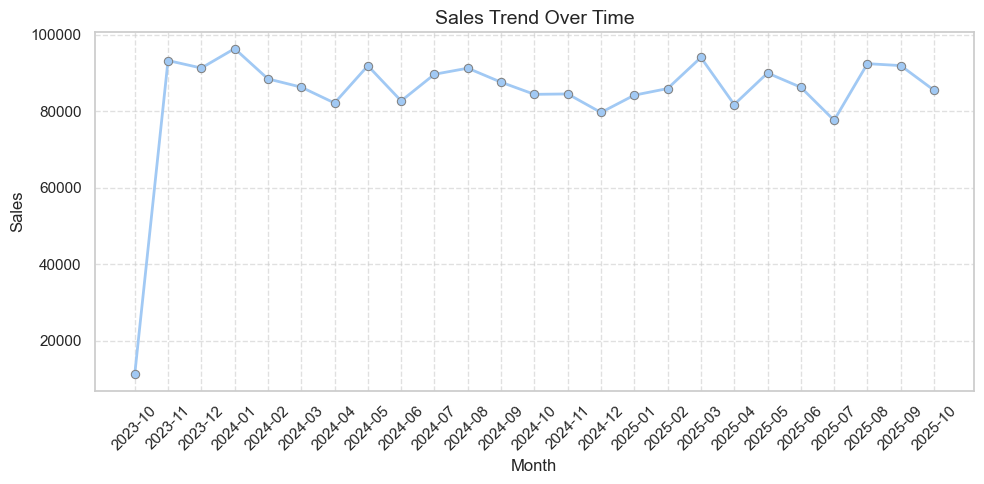

In [97]:
monthly_sales = df.groupby(df['date_added'].dt.to_period('M'))['sold_quantity'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10,5))

sns.lineplot(x=monthly_sales.index,y=monthly_sales.values,marker='o',markeredgecolor="grey",linewidth=2)

plt.title("Sales Trend Over Time", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Insights from “Sales Trend Over Time” Chart

###  Overall Trend
- Sales show a **stable upward trend** after an initial sharp increase.
- From late 2023 onward, sales consistently remain in the **80,000–95,000 range**, indicating steady business performance.

###  Initial Spike
- A significant jump is observed from **October 2023 (~11,000)** to **November 2023 (~93,000)**.
- This could be due to:
  - Business launch or expansion
  - Seasonal demand (e.g., holiday sales)
  - Promotional campaigns

###  Fluctuations Over Time
- Sales exhibit **moderate fluctuations** month-to-month rather than extreme volatility.
- Peaks are seen around:
  - **January 2024 (~96,000)**
  - **March 2025 (~94,000)**
  - **August 2025 (~92,000)**
- Dips occur around:
  - **April 2024 (~82,000)**
  - **December 2024 (~80,000)**
  - **July 2025 (~78,000)**

###  Consistency & Stability
- After the initial surge, sales stabilize, suggesting:
  - A **mature and predictable sales cycle**
  - Strong customer retention and consistent demand

###  Possible Seasonality
- Slight recurring peaks and dips may indicate **seasonal patterns**, though not highly pronounced.
- End-of-year dip (December) could suggest:
  - Reduced activity or post-peak normalization

---

###  Key Takeaways

- The business demonstrates **strong and consistent sales performance** over time.
- **No long-term decline**, indicating healthy growth and sustainability.
- **Fluctuations are minor**, making forecasting more reliable.
- Early spike suggests a **one-time event or ramp-up phase**.

---

###  Conclusion

Overall, the sales trend reflects a stable and well-performing business with consistent monthly revenue after an initial growth phase. While there are minor fluctuations, the absence of sharp declines indicates resilience and steady demand. With some evidence of seasonality, leveraging peak periods and addressing low-performing months could further optimize revenue growth.

#  **summary of findings**

This analysis of Blinkit's inventory dataset highlights key patterns in product demand, stock management, and sales performance.

- A strong positive relationship exists between **demand index and sold quantity**, indicating demand-driven sales behavior.
- **Inventory turnover** is highly correlated with sales, making it a reliable indicator of product performance.
- Certain products face **stockout risks**, where demand exceeds available inventory.
- At the same time, some items are **overstocked or dead stock**, leading to inefficient capital utilization.
- Category-level analysis shows that some categories consistently outperform others in terms of sales.
- Time-based analysis reveals an overall **upward sales trend**, suggesting growing demand.

Overall, the dataset demonstrates opportunities to improve **inventory efficiency, reduce wastage, and align stock levels with demand patterns**.

# **Business Recommendations**

Based on the analysis, the following actions are recommended to optimize inventory management:

### 1. Optimize Reorder Strategy
- Increase reorder frequency for **high-demand, low-stock products**
- Use demand index to dynamically adjust reorder levels

### 2. Reduce Overstock & Dead Stock
- Identify slow-moving products and:
  - Apply discounts
  - Bundle with fast-selling items
- Avoid over-purchasing low-demand products

### 3. Improve Demand Forecasting
- Use historical demand and sales trends to predict future demand
- Implement data-driven forecasting models

### 4. Manage Perishable Inventory Efficiently
- Prioritize selling items with **low days to expiry**
- Use targeted promotions for near-expiry products

### 5. Focus on High-Performing Categories
- Allocate more inventory and marketing efforts to top-selling categories
- Expand product variety in high-demand segments

### 6. Monitor Key Metrics
Track the following KPIs regularly:
- Inventory Turnover Ratio
- Stockout Rate
- Dead Stock Percentage
- Demand-Stock Gap

Implementing these strategies can help reduce losses, improve customer satisfaction, and increase overall operational efficiency.